# Twin experiments — MAPE evolution (Figure 7)

Mean Absolute Percentage Error of the best individual at each generation,
per parameter, with respect to the reference values of Table 1
(Manuscript Figure 7, Section 3.4.2).

Inputs: `data/ga_logbook_{STATION}_{MODE}.parquet`, `parameters.yaml`.
Output: `figures/Figure_7.{pdf,png}`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml


def _project_root(marker: str = "pyproject.toml") -> Path:
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Project root marker {marker!r} not found.")


PROJECT_ROOT = _project_root()
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

with open(PROJECT_ROOT / "parameters.yaml") as f:
    PARAMS = yaml.safe_load(f)
REF = PARAMS["model_parameters"]["reference"]
GA = PARAMS["genetic_algorithm"]
mode = GA["mode"]
experiments = GA["experiments"]

DISPLAY = {"BARENTS": "BARENTS", "PAPA": "PAPA", "Bay_of_Biscay": "BISCAY",
           "BATS": "BATS", "Canaries": "CANARY", "HOT": "HOT", "MERGED": "MERGED"}

PARAM_ORDER = ["energy_transfert", "tr_0", "gamma_tr", "lambda_temperature_0", "gamma_lambda_temperature"]
PARAM_LABELS = {
    "energy_transfert": r"$E$",
    "tr_0": r"$\tau_{r_0}$",
    "gamma_tr": r"$\gamma_{\tau_r}$",
    "lambda_temperature_0": r"$\lambda_0$",
    "gamma_lambda_temperature": r"$\gamma_\lambda$",
}

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

## For each experiment, extract the best individual per generation

In [2]:
def _best_params_per_gen(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for gen, gen_df in df.groupby(level="Generation"):
        best_idx = gen_df[("Weighted_fitness", "Weighted_fitness")].idxmax()
        params = gen_df.loc[best_idx, "Parametre"]
        rows.append({"Generation": gen, **params.to_dict()})
    return pd.DataFrame(rows).set_index("Generation")


def _global_best_generation(df: pd.DataFrame) -> int:
    """Generation that contains the all-time best individual (highest Weighted_fitness)."""
    best_idx = df[("Weighted_fitness", "Weighted_fitness")].idxmax()
    return int(best_idx[0])  # MultiIndex: (Generation, Is_From_Previous_Generation, Individual)


def _mape(best_df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        p: (best_df[p] - REF[p]).abs() / abs(REF[p]) * 100 for p in PARAM_ORDER
    })


mape_by_exp = {}
best_gen_by_exp = {}
for sid in experiments:
    df = pd.read_parquet(DATA_DIR / f"ga_logbook_{sid}_{mode}.parquet")
    mape_by_exp[DISPLAY[sid]] = _mape(_best_params_per_gen(df))
    best_gen_by_exp[DISPLAY[sid]] = _global_best_generation(df)

best_gen_by_exp

{'BARENTS': 4,
 'PAPA': 7,
 'BISCAY': 3,
 'BATS': 7,
 'CANARY': 8,
 'HOT': 8,
 'MERGED': 4}

## Figure 7 — MAPE per parameter across generations and experiments

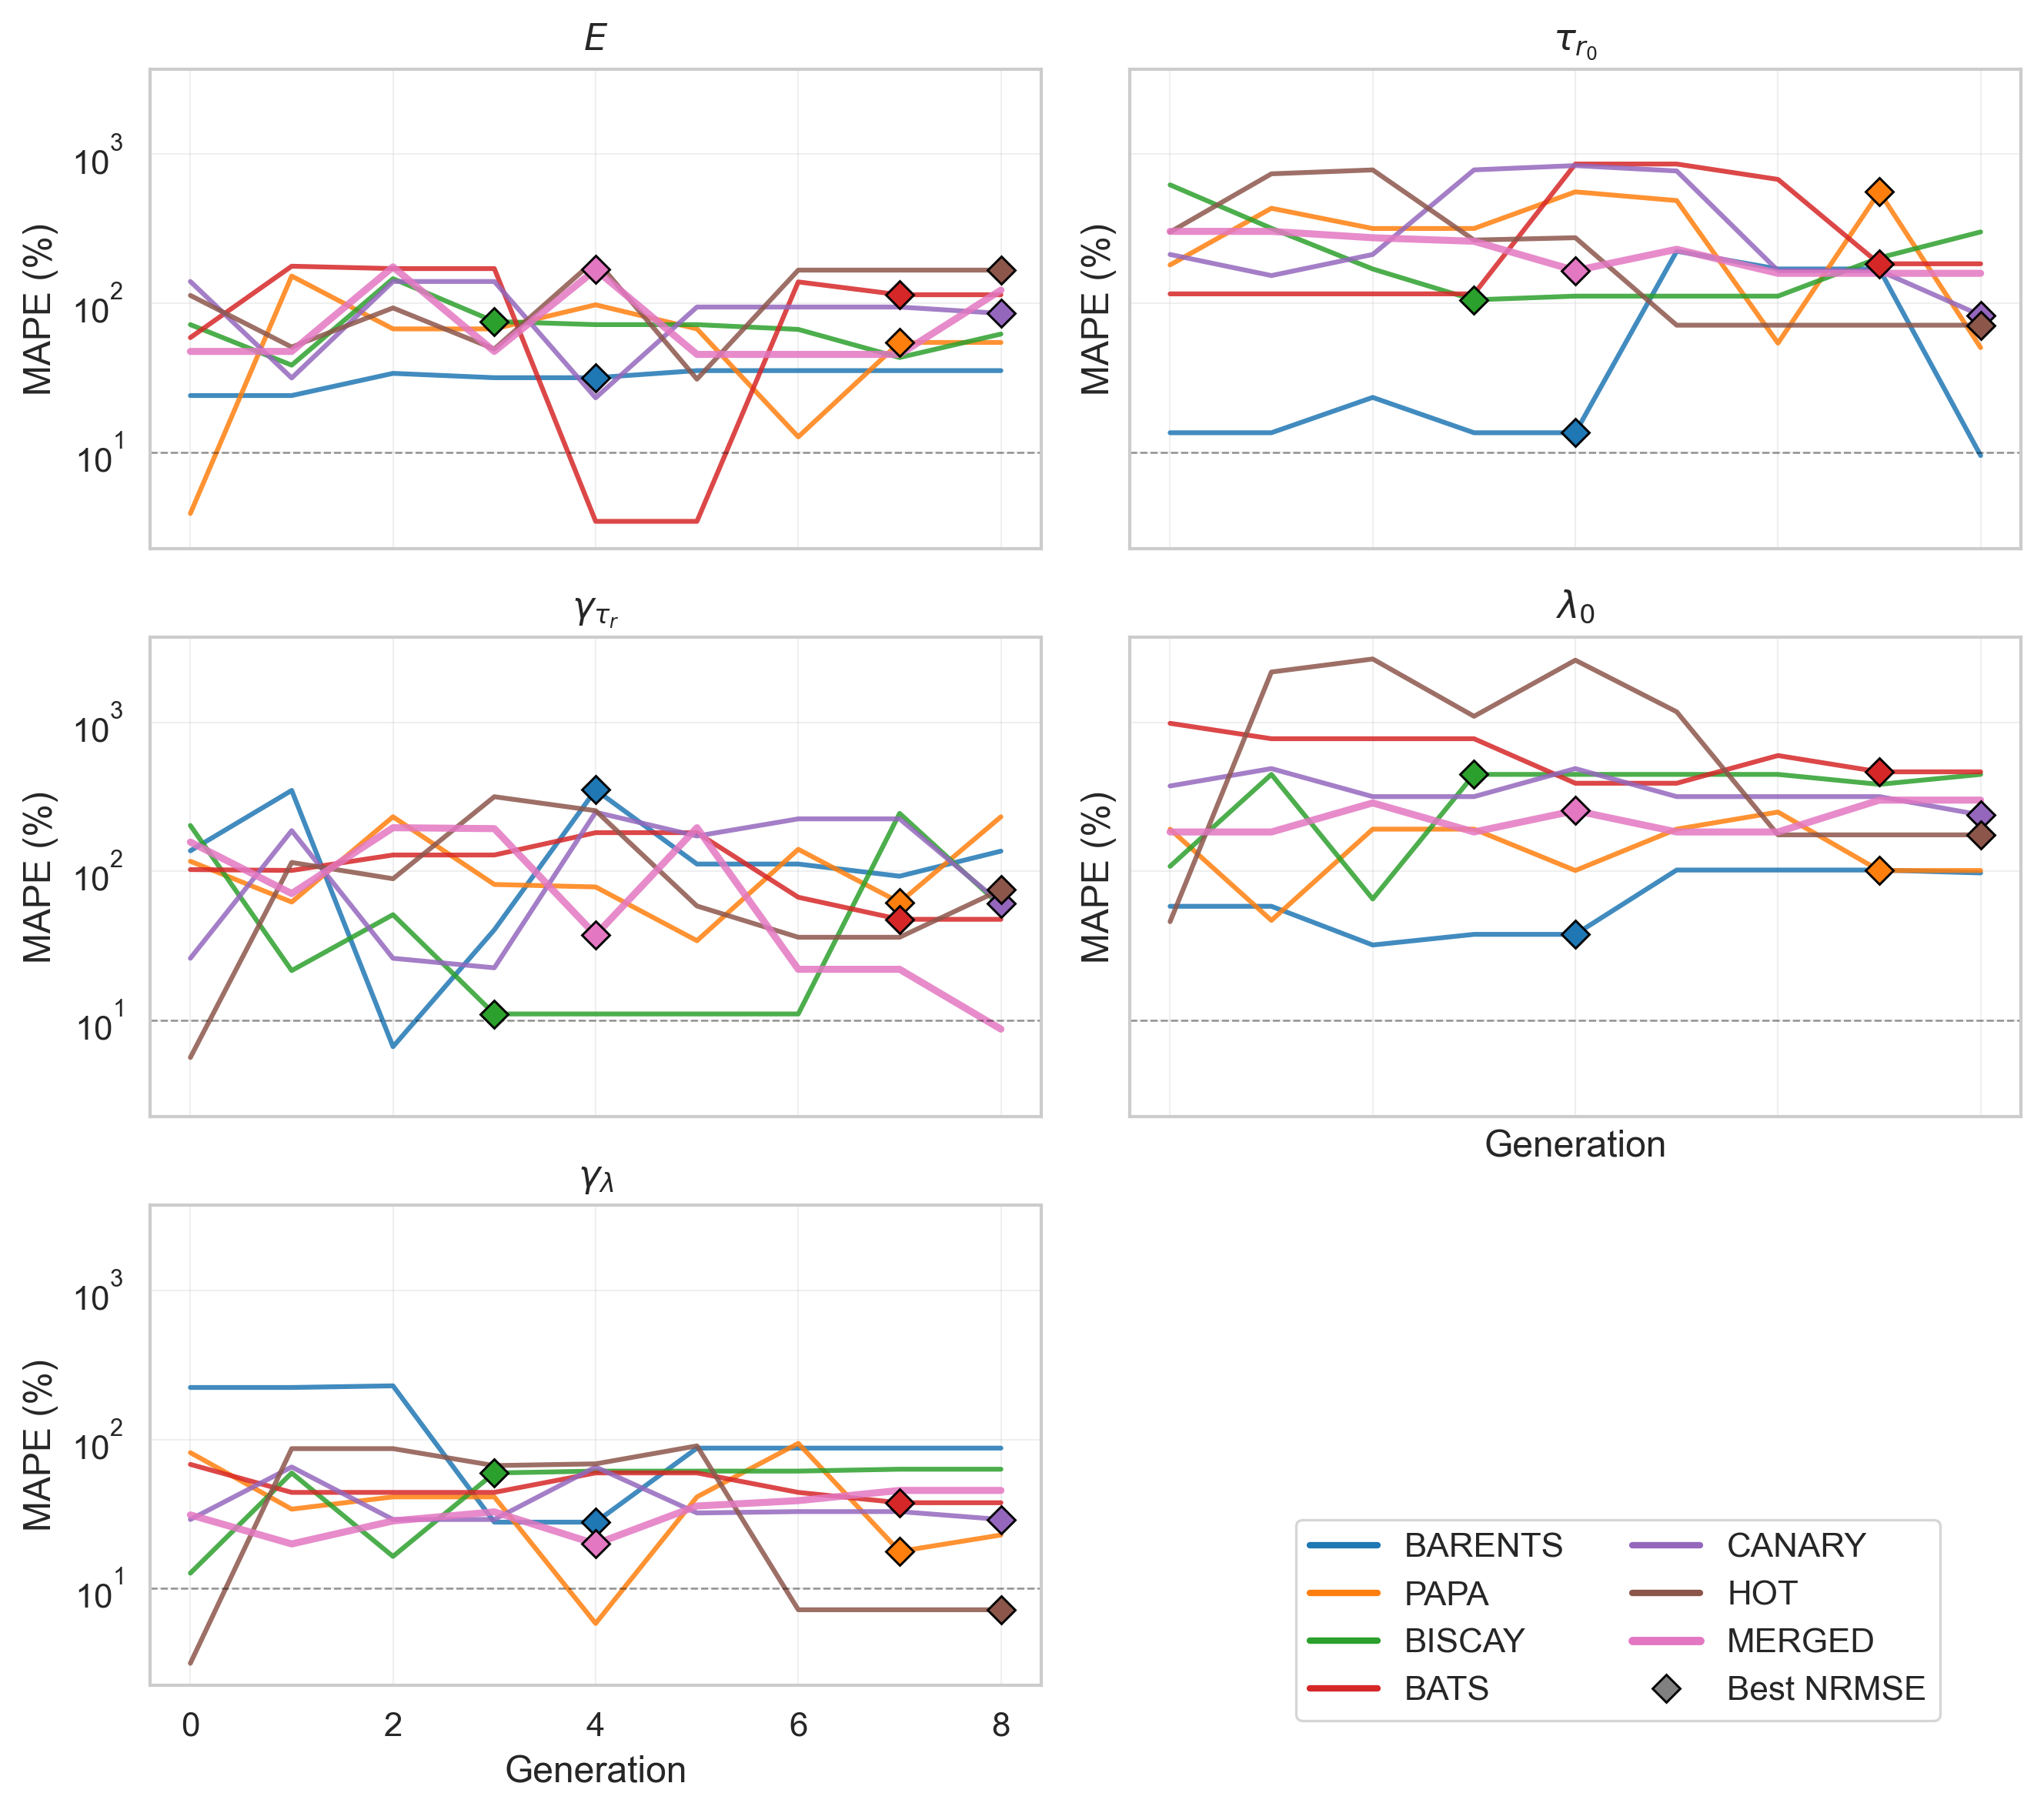

In [3]:
from matplotlib.lines import Line2D

exp_names = list(mape_by_exp)
color_map = dict(zip(exp_names, sns.color_palette("tab10", len(exp_names)), strict=True))

fig, axes = plt.subplots(3, 2, figsize=(9, 8), sharex=True, sharey=True, dpi=300)
axes = axes.flatten()

for i, param in enumerate(PARAM_ORDER):
    ax = axes[i]
    for exp in exp_names:
        series = mape_by_exp[exp][param]
        linewidth = 2.2 if exp == "MERGED" else 1.5
        ax.plot(series.index, series.values, color=color_map[exp],
                linewidth=linewidth, alpha=0.85)
        # Diamond marker at the generation containing the global best individual
        best_gen = best_gen_by_exp[exp]
        if best_gen in series.index:
            ax.plot(best_gen, series.loc[best_gen], marker="D", markersize=6,
                    color=color_map[exp], markeredgecolor="black", markeredgewidth=0.7,
                    zorder=10, linestyle="")
    ax.set_title(PARAM_LABELS[param], fontweight="bold")
    ax.set_ylabel("MAPE (%)")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.axhline(10, color="black", linestyle="--", linewidth=0.6, alpha=0.4)
axes[-1].axis("off")
axes[-2].set_xlabel("Generation")
axes[-3].set_xlabel("Generation")

legend_handles = [
    Line2D([0], [0], color=color_map[exp], linewidth=2.0 if exp != "MERGED" else 2.6, label=exp)
    for exp in exp_names
]
legend_handles.append(
    Line2D([0], [0], marker="D", color="gray", markersize=6,
           markeredgecolor="black", markeredgewidth=0.7, linestyle="", label="Best NRMSE")
)
fig.legend(handles=legend_handles, loc="lower right", ncol=2, frameon=True,
           bbox_to_anchor=(0.95, 0.05))
plt.tight_layout()
fig.savefig(FIGURES_DIR / "Figure_7.pdf", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "Figure_7.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()